# Set sub-grid widths for selected channels

In [4]:
import os
import sys
sys.path.insert(0,os.path.abspath('src/'))

In [5]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import xarray as xr

import os
from datetime import date, datetime

import matplotlib.pyplot as plt
from topo_edit_util import inspect_topo, create_soc_topo_table

## Get input topography data set

In [6]:
path_root = './'
file_root = 'topo.'

grid = 'tx2_3v3'
topo_src = 'SRTM15_V2.4'
nsub = 'sub150'
edit_no = 2
case = 'SmL1.0_C1.0'
depth_var_in = 'D_edit2'


In [7]:
path_in = path_root

file_in = file_root + nsub +  '.' + grid + '.' + topo_src + '.edit' + '{:d}'.format(edit_no) + '.' + case + '.nc'

# This is the current default input file
#file_in = 'ocean_topo_tx2_3v2_240501.nc'

print(path_in+file_in)
dss = xr.open_dataset(path_in+file_in)
dss

./topo.sub150.tx2_3v3.SRTM15_V2.4.edit2.SmL1.0_C1.0.nc


<xarray.Dataset> Size: 21MB
Dimensions:     (lath: 480, lonh: 540, latq: 481, lonq: 541, nEdits: 367)
Coordinates:
  * lath        (lath) float64 4kB -81.56 -81.46 -81.36 ... 89.33 89.6 89.86
  * lonh        (lonh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * latq        (latq) float64 4kB -81.61 -81.51 -81.41 ... 89.46 89.72 89.91
  * lonq        (lonq) float64 4kB -287.0 -286.3 -285.7 ... 71.67 72.33 73.0
Dimensions without coordinates: nEdits
Data variables: (12/19)
    geolon      (lath, lonh) float64 2MB ...
    geolat      (lath, lonh) float64 2MB ...
    geolonb     (latq, lonq) float64 2MB ...
    geolatb     (latq, lonq) float64 2MB ...
    z           (lath, lonh) float32 1MB ...
    ocn_frac    (lath, lonh) float32 1MB ...
    ...          ...
    orig_mask   (lath, lonh) int32 1MB ...
    D_interp    (lath, lonh) float32 1MB ...
    D_edit2     (lath, lonh) float32 1MB ...
    iEdit       (nEdits) int32 1kB ...
    jEdit       (nEdits) int32 1kB ...
    zEdit       (nEdits) float64 3kB ...
Attributes:
    Description:               Ocean Topography Statistics on MOM6 Grid
    Creator:                   Frank Bryan
    Created:                   20260226
    Generating Code:           create_model_topo.f90
    Model Grid Version:        tx2_3v3
    Source Topography Data:    /glade/work/bryan/Observations/Topography/SRTM...
    Edit History:              Hand Edit + Lake Fill 02/27/2026
    Manual edits updated on::  2026-03-04T14:46:33.511255
    By::                       Frank Bryan (bryan@ucar.edu)
    url:                       https://github.com/NCAR/tx2_3/topography/

In [8]:
soc_table = create_soc_topo_table()

## Set up output files

In [9]:
today = datetime.today()

path_out = path_in
print(path_out)
file_out_chan = 'channels_' + grid + '_' + today.strftime("%y%m%d") + '.txt'
print('channel width file : ',file_out_chan)

fmt_out = "{0:s}, {1:8.2f}, {2:8.2f}, {3:8.2f}, {4:8.2f}, {5:10.1f} ! {6:s}\n"

./
channel width file :  channels_tx2_3v3_260304.txt


## Selected Straits

### Strait of Gibralter

{'lat': 35.92, 'lon': -5.75, 'depth': 284.0, 'width': 10.0}


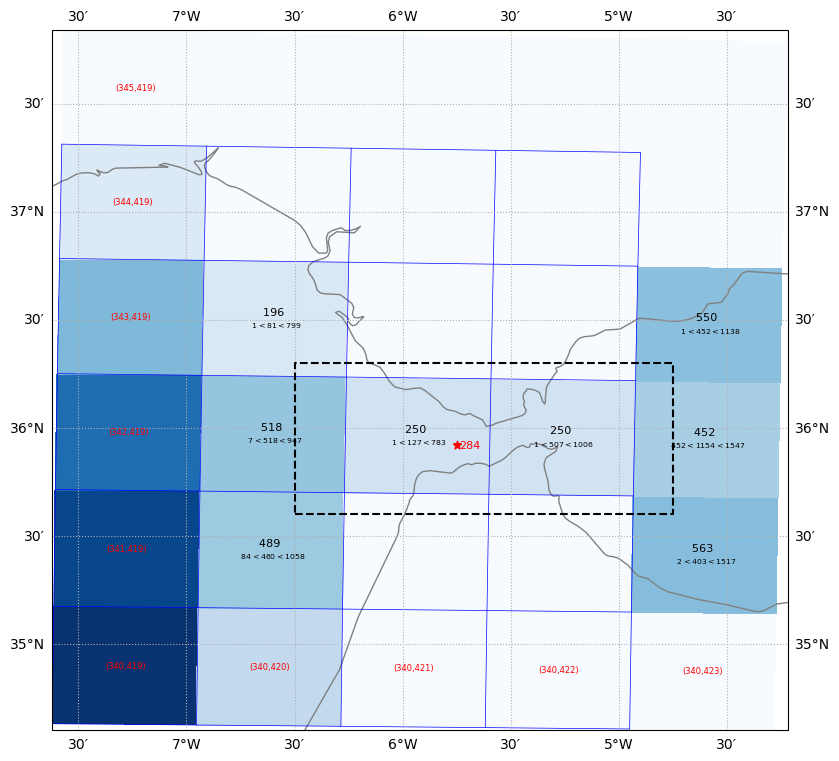

In [10]:
place = 'St. of Gibralter'
print(soc_table[place])
lon_beg = -7
lon_end = -4
lat_beg = 35
lat_end = 38
zmax = 1300.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

lon1 = -6.5
lat1 = 35.6
lon2 = -4.75
lat2 = 36.3
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')


In [11]:
width = 12.0e3
print('width = ',width)

with open(path_out+file_out_chan,'w') as f:
    line = fmt_out.format("U_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

width =  12000.0


### Bosphorus

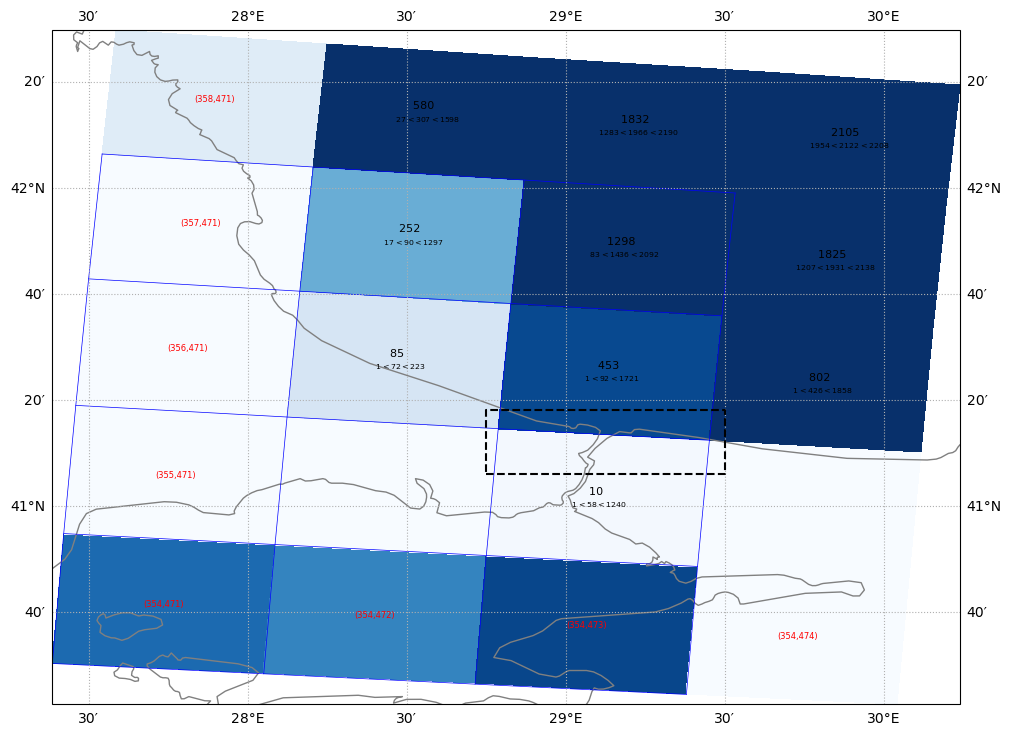

In [12]:
## Black Sea / Bosphorus
place = 'Bosphorus St.'
lon_beg = 28
lon_end = 30.5
lat_beg = 40.5
lat_end = 42.5
zmax = 500.


ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

lon1 = 28.75
lat1 = 41.1
lon2 = 29.5
lat2 = 41.3
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')


In [13]:
width = 5.0e3
print('width = ',width)

with open(path_out+file_out_chan,'a') as f:
    line = fmt_out.format("V_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

width =  5000.0


### Dardanelles

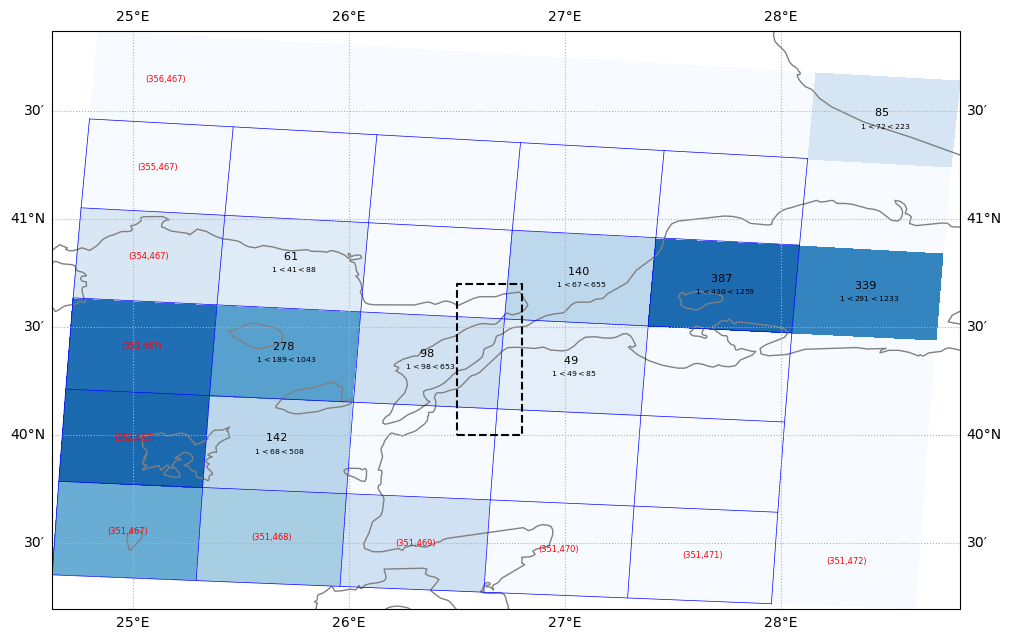

In [14]:
place = 'Dardanelles'
lon_beg = 25
lon_end = 29
lat_beg = 39.5
lat_end = 42
zmax = 500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

lon1 = 26.5
lat1 = 40.
lon2 = 26.8
lat2 = 40.7
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')


In [15]:
width = 5.0e3
print('width = ',width)

with open(path_out+file_out_chan,'a') as f:
    line = fmt_out.format("U_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

width =  5000.0


### Lombok Strait

{'lat': -8.9, 'lon': 116.0, 'depth': 350.0, 'width': 22.0}


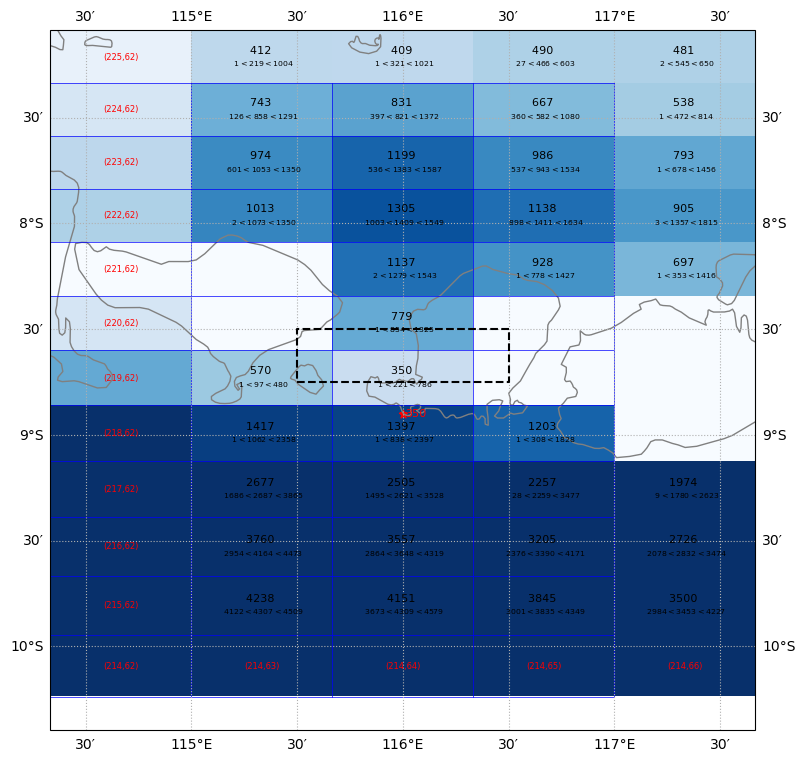

In [16]:
place = 'Lombok St.'
print(soc_table[place])
lon_beg = -245.5
lon_end = -242.
lat_beg = -10
lat_end = -7.
zmax = 1500.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

lon1 = 115.5
lon2 = 116.5
lat1 = -8.75
lat2 = -8.5
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')


In [17]:
width = soc_table[place]['width']*1000.
print('width = ',width)

with open(path_out+file_out_chan,'a') as f:
    line = fmt_out.format("V_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

width =  22000.0


### Bab El-Mandeb

{'lat': 13.73, 'lon': 42.5, 'depth': 137.0, 'width': 32.0}


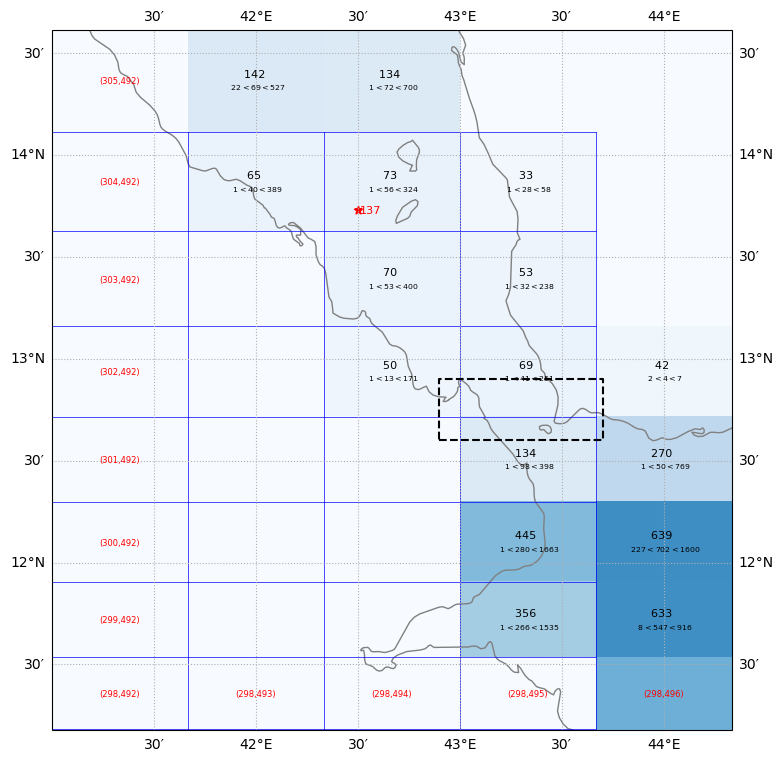

In [18]:
place = 'Bab El-Mandeb'
print(soc_table[place])
lon_beg = 41.5
lon_end = 44.5
lat_beg = 11.5
lat_end = 14.75
zmax = 1000.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax,place=soc_table[place])

lon1 = 42.9
lon2 = 43.7
lat1 = 12.6
lat2 = 12.9
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')


In [19]:
width = soc_table[place]['width']*1000.
print('width = ',width)

with open(path_out+file_out_chan,'a') as f:
    line = fmt_out.format("V_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

width =  32000.0


### St of Hormuz

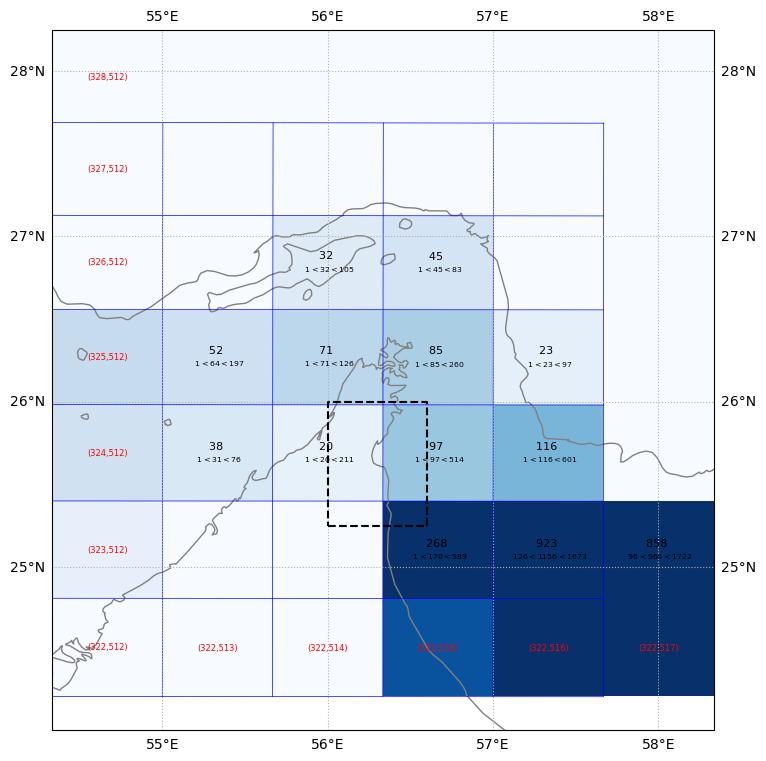

In [20]:
place ='St. of Hormuz'
lon_beg = 54.5
lon_end = 59
lat_beg = 24.5
lat_end = 28.5
zmax = 250.

ax=inspect_topo(dss,depth_var_in,lon_beg,lon_end,lat_beg,lat_end,zmax)

lon1 = 56
lon2 = 56.6
lat1 = 25.25
lat2 = 26.0
xbox = [lon1, lon2, lon2, lon1, lon1]
ybox = [lat1, lat1, lat2, lat2, lat1]
ax.plot(xbox,ybox,linestyle='dashed',color='k')


In [21]:
width = 5.
print('width = ',width)

with open(path_out+file_out_chan,'a') as f:
    line = fmt_out.format("V_width",lon1,lon2,lat1,lat2,width,place)
    f.write(line)

width =  5.0
